# AI assistant usage in students' life

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('ai_assistant_usage_student_life.csv')
df

,SessionID,StudentLevel,Discipline,SessionDate,SessionLengthMin,TotalPrompts,TaskType,AI_AssistanceLevel,FinalOutcome,UsedAgain,SatisfactionRating
0,SESSION00001,Undergraduate,Computer Science,2024-11-03,31.20,11,Studying,2,Assignment Completed,True,1.0
1,SESSION00002,Undergraduate,Psychology,2024-08-25,13.09,6,Studying,3,Assignment Completed,True,2.0
2,SESSION00003,Undergraduate,Business,2025-01-12,19.22,5,Coding,3,Assignment Completed,True,3.3
3,SESSION00004,Undergraduate,Computer Science,2025-05-06,3.70,1,Coding,3,Assignment Completed,True,3.5
4,SESSION00005,Undergraduate,Psychology,2025-03-18,28.12,9,Writing,3,Assignment Completed,True,2.9
...,...,...,...,...,...,...,...,...,...,...,...
9995,SESSION09996,Undergraduate,Psychology,2024-07-20,28.41,5,Studying,3,Assignment Completed,True,4.2
9996,SESSION09997,High School,Business,2024-11-11,13.98,6,Writing,5,Assignment Completed,True,5.0
9997,SESSION09998,Undergraduate,Biology,2024-09-11,10.78,2,Studying,3,Idea Drafted,True,3.5
9998,SESSION09999,Undergraduate,Business,2024-10-27,30.88,7,Writing,3,Assignment Completed,False,4.3


In [3]:
df.head()

,SessionID,StudentLevel,Discipline,SessionDate,SessionLengthMin,TotalPrompts,TaskType,AI_AssistanceLevel,FinalOutcome,UsedAgain,SatisfactionRating
0,SESSION00001,Undergraduate,Computer Science,2024-11-03,31.20,11,Studying,2,Assignment Completed,True,1.0
1,SESSION00002,Undergraduate,Psychology,2024-08-25,13.09,6,Studying,3,Assignment Completed,True,2.0
2,SESSION00003,Undergraduate,Business,2025-01-12,19.22,5,Coding,3,Assignment Completed,True,3.3
3,SESSION00004,Undergraduate,Computer Science,2025-05-06,3.70,1,Coding,3,Assignment Completed,True,3.5
4,SESSION00005,Undergraduate,Psychology,2025-03-18,28.12,9,Writing,3,Assignment Completed,True,2.9


In [4]:
type(df["SessionDate"])

pandas.core.series.Series

In [5]:
df["SessionDate"]=pd.to_datetime(df["SessionDate"])
df.head()

,SessionID,StudentLevel,Discipline,SessionDate,SessionLengthMin,TotalPrompts,TaskType,AI_AssistanceLevel,FinalOutcome,UsedAgain,SatisfactionRating
0,SESSION00001,Undergraduate,Computer Science,2024-11-03,31.20,11,Studying,2,Assignment Completed,True,1.0
1,SESSION00002,Undergraduate,Psychology,2024-08-25,13.09,6,Studying,3,Assignment Completed,True,2.0
2,SESSION00003,Undergraduate,Business,2025-01-12,19.22,5,Coding,3,Assignment Completed,True,3.3
3,SESSION00004,Undergraduate,Computer Science,2025-05-06,3.70,1,Coding,3,Assignment Completed,True,3.5
4,SESSION00005,Undergraduate,Psychology,2025-03-18,28.12,9,Writing,3,Assignment Completed,True,2.9


In [6]:
df["SessionDate"].head()

0   2024-11-03
1   2024-08-25
2   2025-01-12
3   2025-05-06
4   2025-03-18
Name: SessionDate, dtype: datetime64[ns]

In [7]:
df.isnull().sum()

SessionID             0
StudentLevel          0
Discipline            0
SessionDate           0
SessionLengthMin      0
TotalPrompts          0
TaskType              0
AI_AssistanceLevel    0
FinalOutcome          0
UsedAgain             0
SatisfactionRating    0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

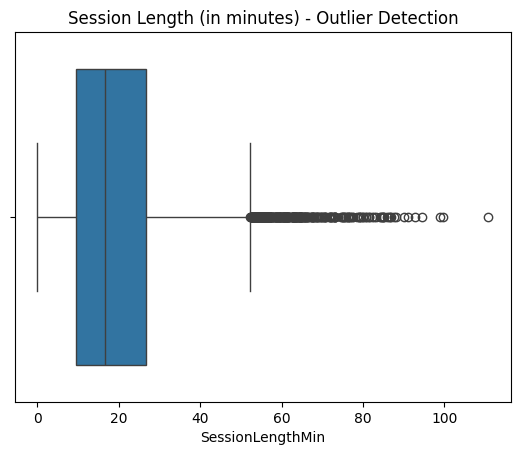

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df['SessionLengthMin'])
plt.title("Session Length (in minutes) - Outlier Detection")
plt.show()


In [15]:
# Remove sessions longer than 90 minutes (optional: 60 if you want to be stricter)
df_cleaned = df[df['SessionLengthMin'] <= 90]

# Check how many rows were removed
print("Original rows:", len(df))
print("After removing outliers:", len(df_cleaned))

Original rows: 10000
After removing outliers: 9993


In [16]:
df = df_cleaned

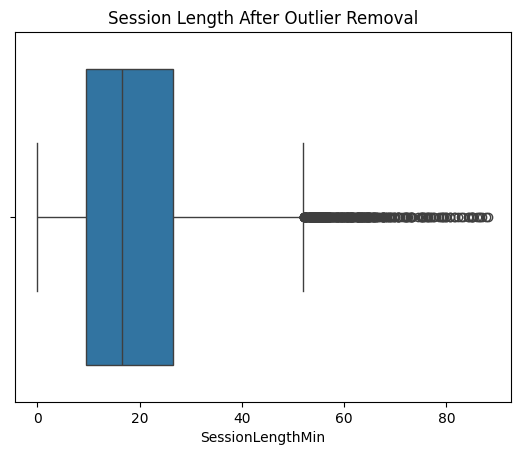

In [17]:
sns.boxplot(x=df['SessionLengthMin'])
plt.title("Session Length After Outlier Removal")
plt.show()

In [20]:
df_cleaned

,SessionID,StudentLevel,Discipline,SessionDate,SessionLengthMin,TotalPrompts,TaskType,AI_AssistanceLevel,FinalOutcome,UsedAgain,SatisfactionRating
0,SESSION00001,Undergraduate,Computer Science,2024-11-03,31.20,11,Studying,2,Assignment Completed,True,1.0
1,SESSION00002,Undergraduate,Psychology,2024-08-25,13.09,6,Studying,3,Assignment Completed,True,2.0
2,SESSION00003,Undergraduate,Business,2025-01-12,19.22,5,Coding,3,Assignment Completed,True,3.3
3,SESSION00004,Undergraduate,Computer Science,2025-05-06,3.70,1,Coding,3,Assignment Completed,True,3.5
4,SESSION00005,Undergraduate,Psychology,2025-03-18,28.12,9,Writing,3,Assignment Completed,True,2.9
...,...,...,...,...,...,...,...,...,...,...,...
9995,SESSION09996,Undergraduate,Psychology,2024-07-20,28.41,5,Studying,3,Assignment Completed,True,4.2
9996,SESSION09997,High School,Business,2024-11-11,13.98,6,Writing,5,Assignment Completed,True,5.0
9997,SESSION09998,Undergraduate,Biology,2024-09-11,10.78,2,Studying,3,Idea Drafted,True,3.5
9998,SESSION09999,Undergraduate,Business,2024-10-27,30.88,7,Writing,3,Assignment Completed,False,4.3


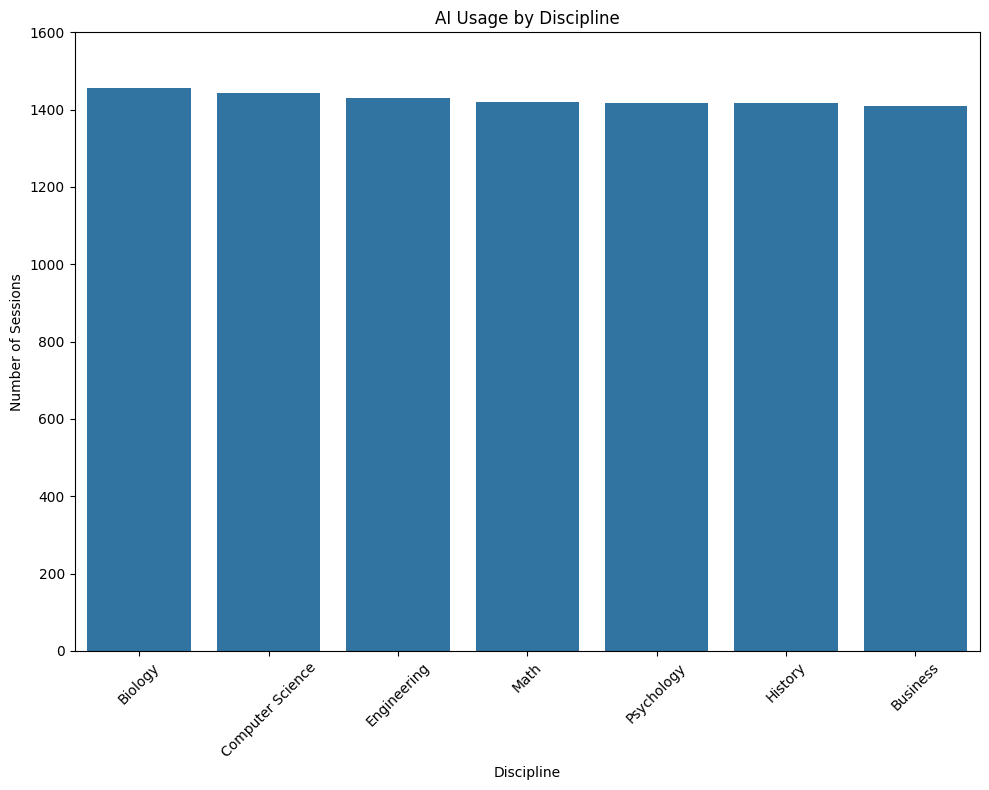

In [23]:
plt.figure(figsize=(10,8))
sns.countplot(data=df, x='Discipline', order=df['Discipline'].value_counts().index)
plt.title("AI Usage by Discipline")
plt.xticks(rotation=45)
plt.ylabel("Number of Sessions")
plt.ylim(0,1600)
plt.tight_layout()
plt.show()

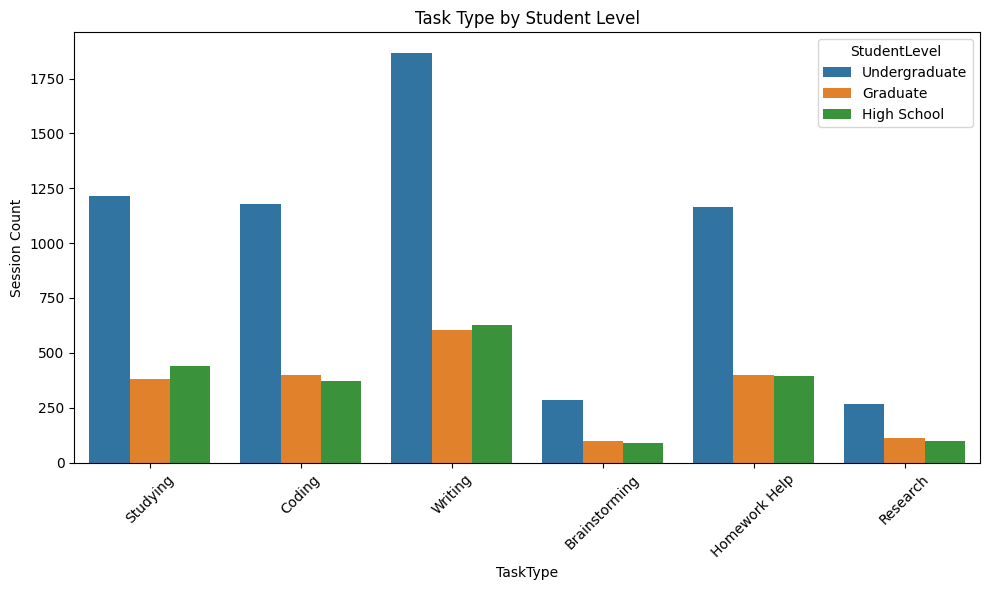

In [24]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='TaskType', hue='StudentLevel')
plt.title("Task Type by Student Level")
plt.ylabel("Session Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

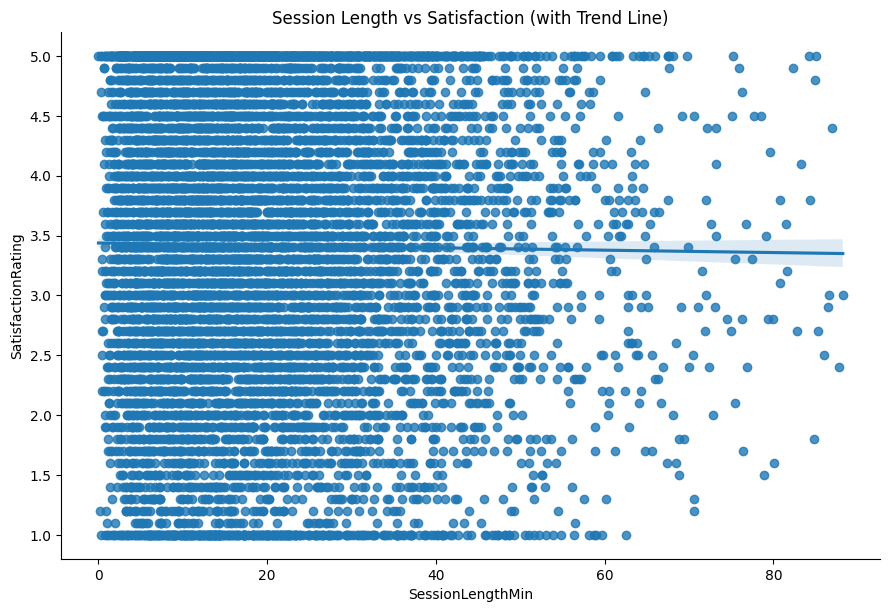

In [26]:
sns.lmplot(data=df, x='SessionLengthMin', y='SatisfactionRating', height=6, aspect=1.5)
plt.title("Session Length vs Satisfaction (with Trend Line)")
plt.show()

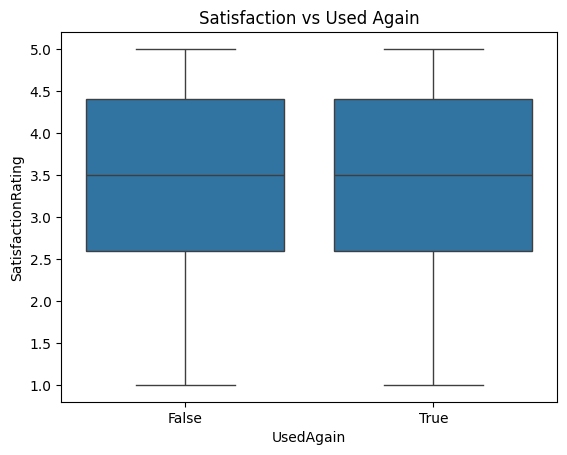

In [28]:
sns.boxplot(data=df, x='UsedAgain', y='SatisfactionRating')
plt.title("Satisfaction vs Used Again")
plt.show()

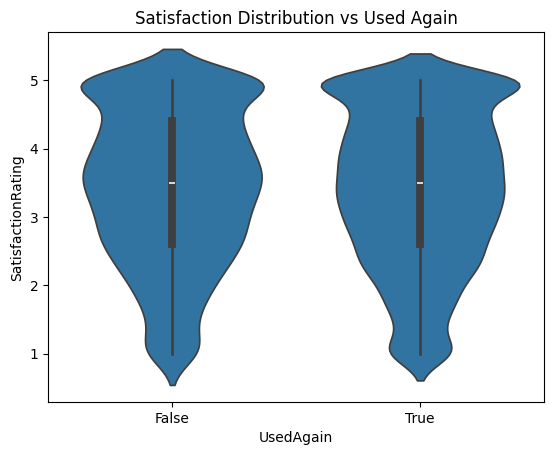

In [29]:
sns.violinplot(data=df, x='UsedAgain', y='SatisfactionRating')
plt.title("Satisfaction Distribution vs Used Again")
plt.show()

In [30]:
df.groupby('UsedAgain')['SatisfactionRating'].describe()

,count,mean,std,min,25%,50%,75%,max
UsedAgain,,,,,,,,
False,2936.0,3.434366,1.128727,1.0,2.6,3.5,4.4,5.0
True,7057.0,3.410684,1.149462,1.0,2.6,3.5,4.4,5.0


### Insight Summary: AI Assistant Usage in Student Life

####  Satisfaction v/s Used Again
- Students who reused AI tools and those who didn’t have **very similar satisfaction levels**.
- Satisfaction does **not strongly predict** future reuse.
- Suggests other factors (accessibility, habit, etc.) might influence continued use.

#### Satisfaction vs. AI Assistance Level
- Slight **positive trend** between assistance level and satisfaction.
- Indicates that deeper use of AI tools can result in **better user experience**.

#### Overall Insight
- AI tools are generally well-received, but **usage patterns are not solely driven by satisfaction**.


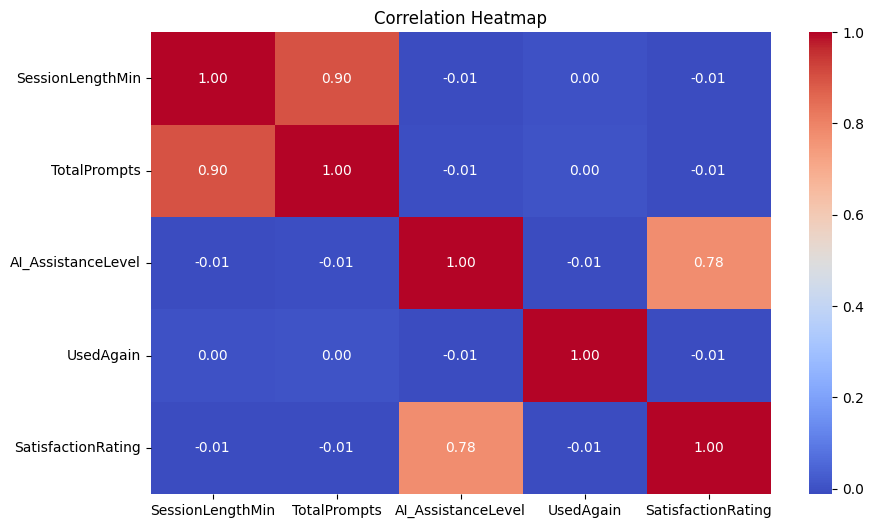

In [31]:
# Compute correlation matrix
corr_matrix = df.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [33]:
print(df.columns.tolist())

['SessionID', 'StudentLevel', 'Discipline', 'SessionDate', 'SessionLengthMin', 'TotalPrompts', 'TaskType', 'AI_AssistanceLevel', 'FinalOutcome', 'UsedAgain', 'SatisfactionRating']


C:\Users\Asus\AppData\Local\Temp\ipykernel_16464\565343748.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Discipline', y='SatisfactionRating', data=df, ci=None)


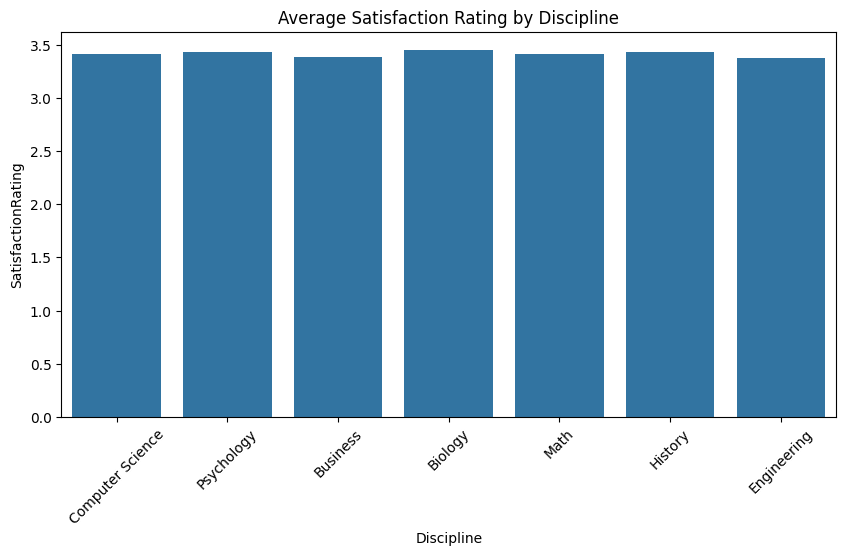

In [34]:
plt.figure(figsize=(10, 5))
sns.barplot(x='Discipline', y='SatisfactionRating', data=df, ci=None)
plt.xticks(rotation=45)
plt.title("Average Satisfaction Rating by Discipline")
plt.show()

C:\Users\Asus\AppData\Local\Temp\ipykernel_16464\3231192051.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='StudentLevel', y='SatisfactionRating', data=df, ci=None)


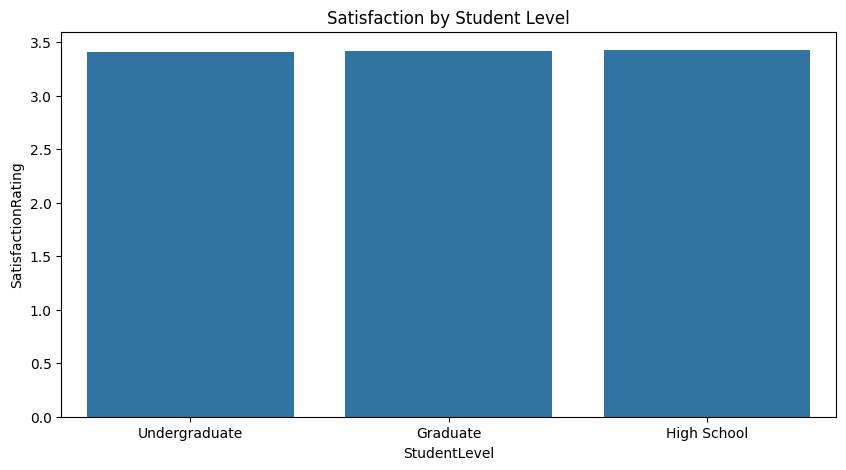

In [35]:
plt.figure(figsize=(10, 5))
sns.barplot(x='StudentLevel', y='SatisfactionRating', data=df, ci=None)
plt.title("Satisfaction by Student Level")
plt.show()

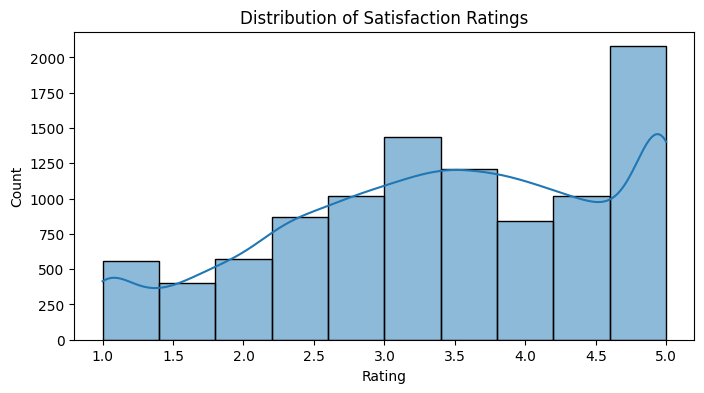

In [36]:
plt.figure(figsize=(8, 4))
sns.histplot(df['SatisfactionRating'], bins=10, kde=True)
plt.title("Distribution of Satisfaction Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

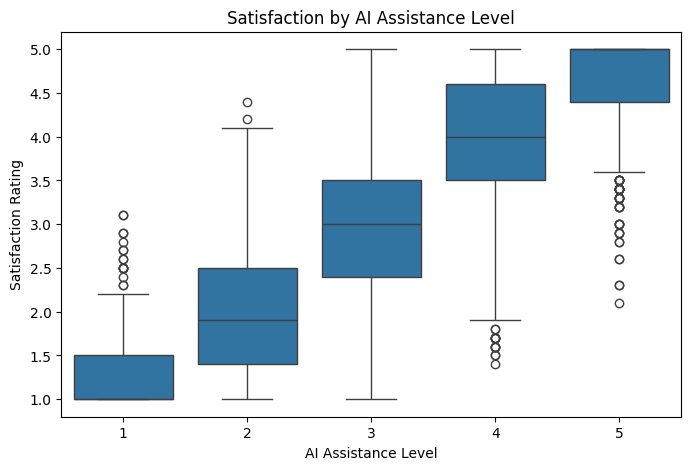

In [37]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='AI_AssistanceLevel', y='SatisfactionRating', data=df)
plt.title("Satisfaction by AI Assistance Level")
plt.xlabel("AI Assistance Level")
plt.ylabel("Satisfaction Rating")
plt.show()

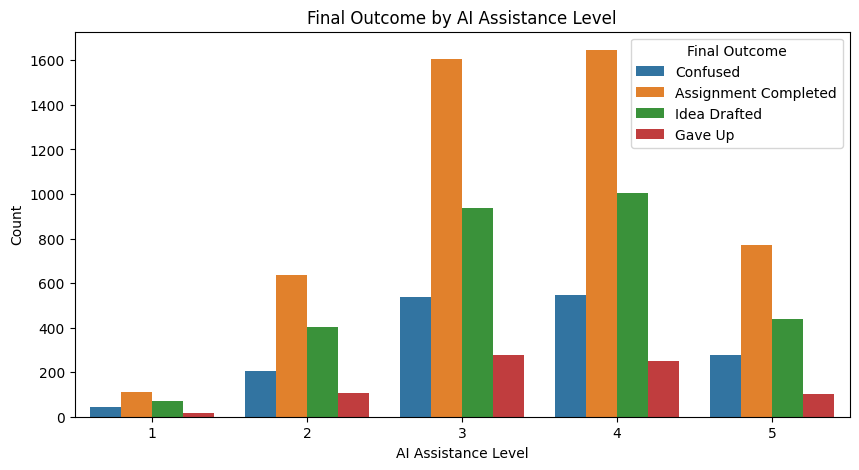

In [38]:
plt.figure(figsize=(10, 5))
sns.countplot(x='AI_AssistanceLevel', hue='FinalOutcome', data=df)
plt.title("Final Outcome by AI Assistance Level")
plt.xlabel("AI Assistance Level")
plt.ylabel("Count")
plt.legend(title='Final Outcome')
plt.show()

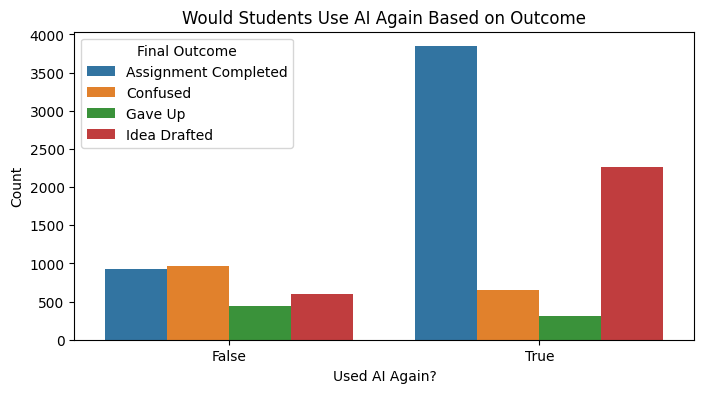

In [40]:
plt.figure(figsize=(8, 4))
sns.countplot(x='UsedAgain', hue='FinalOutcome', data=df)
plt.title("Would Students Use AI Again Based on Outcome")
plt.xlabel("Used AI Again?")
plt.ylabel("Count")
plt.legend(title='Final Outcome')
plt.show()

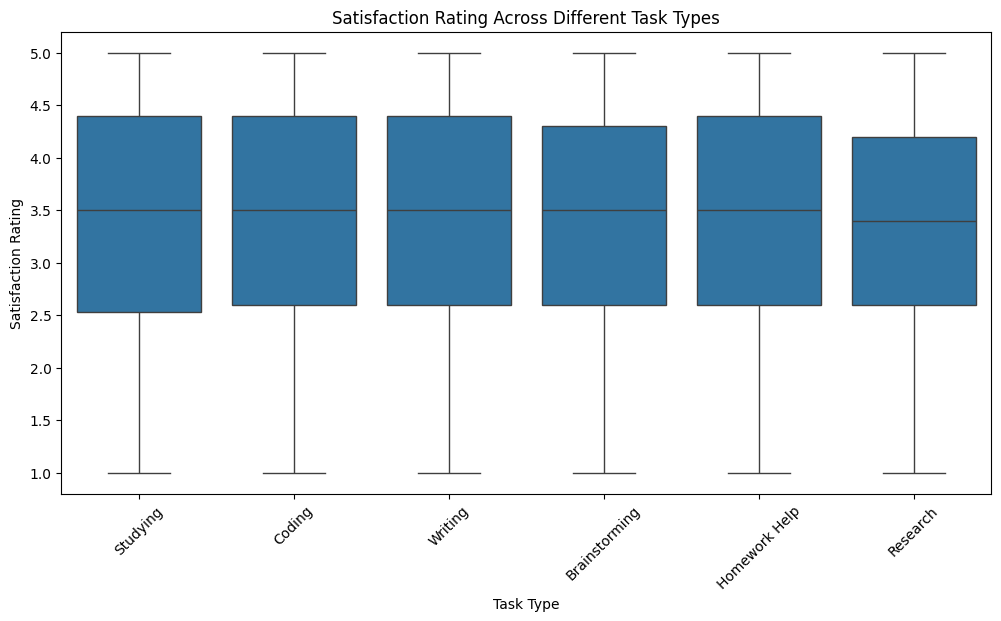

In [41]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='TaskType', y='SatisfactionRating', data=df)
plt.title("Satisfaction Rating Across Different Task Types")
plt.xticks(rotation=45)
plt.xlabel("Task Type")
plt.ylabel("Satisfaction Rating")
plt.show()

In [42]:
# Save cleaned version of dataset
(df_cleaned.to_csv("cleaned_ai_student_data.csv", index=False))
